**Import Libraries**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

**Load Clean Dataset**

In [2]:
df = pd.read_csv("/content/DataCoSupplyChain_clean (1).csv")

df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/content/DataCoSupplyChain_clean (1).csv'

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123753 entries, 0 to 123752
Data columns (total 57 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   type                         123753 non-null  int64  
 1   days_for_shipping_real       123753 non-null  int64  
 2   days_for_shipment_scheduled  123752 non-null  float64
 3   benefit_per_order            123752 non-null  float64
 4   sales_per_customer           123752 non-null  float64
 5   delivery_status              123752 non-null  float64
 6   late_delivery_risk           123752 non-null  float64
 7   category_id                  123752 non-null  float64
 8   category_name                123752 non-null  float64
 9   customer_city                123752 non-null  float64
 10  customer_country             123752 non-null  float64
 11  customer_id                  123752 non-null  float64
 12  customer_segment             123752 non-null  float64
 13 

**Convert Date Columns**

In [ ]:
df['order_date_dateorders'] = pd.to_datetime(df['order_date_dateorders'])
df['shipping_date_dateorders'] = pd.to_datetime(df['shipping_date_dateorders'])

**Feature Engineering**

**1. Logistics Features**

In [ ]:
df['shipping_delay'] = df['days_for_shipping_real'] - df['days_for_shipment_scheduled']

In [ ]:
df['processing_time'] = (df['shipping_date_dateorders'] - df['order_date_dateorders']).dt.days

In [ ]:
df['late_shipment_flag'] = (df['shipping_delay'] > 0).astype(int)

**2. Time Features**

In [ ]:
df['order_year'] = df['order_date_dateorders'].dt.year
df['order_month'] = df['order_date_dateorders'].dt.month
df['order_day'] = df['order_date_dateorders'].dt.day
df['order_weekday'] = df['order_date_dateorders'].dt.weekday

In [ ]:
df['is_weekend'] = (df['order_weekday'] >= 5).astype(int)

**3. Sales and Profit Features**

In [ ]:
# Profit Margin
df['profit_margin'] = df['order_profit_per_order'] / df['sales']

In [ ]:
# Sales per Item
df['sales_per_item'] = df['sales'] / df['order_item_quantity']

In [ ]:
# Profit per Item
df['profit_per_item'] = df['order_profit_per_order'] / df['order_item_quantity']

**4. Order Value Features**

In [ ]:
# Order Size
df['order_size'] = df['order_item_quantity'] * df['sales_per_item']

In [ ]:
# Discount amount
df['discount_amount'] = df['sales'] * df['order_item_discount_rate']

**5. Customer Behavior Features**

In [ ]:
# Customer Order Frequency
df['customer_order_count'] = df.groupby('customer_id')['order_id'].transform('count')

In [ ]:
# Customer Spending
df['customer_total_sales'] = df.groupby('customer_id')['sales'].transform('sum')

In [ ]:
# Average Customer Order Value
df['avg_customer_order'] = df['customer_total_sales'] / df['customer_order_count']

**6. Product Demand Features**

In [ ]:
# Product Demand
df['product_demand'] = df.groupby('product_name')['order_id'].transform('count')

In [ ]:
# Category Demand
df['category_demand'] = df.groupby('category_name')['order_id'].transform('count')

**Validate Feature Engineering**

In [ ]:
# Check Distribution
df[['shipping_delay','profit_margin','order_size']].describe()

,shipping_delay,profit_margin,order_size
count,123752.000000,123752.000000,123752.000000
mean,0.616515,0.109017,182.981901
std,1.498249,0.419869,97.131027
min,-2.000000,-2.750000,9.990000
25%,0.000000,0.062253,119.980003
50%,1.000000,0.242512,179.970001
75%,1.000000,0.336017,249.899994
max,4.000000,0.500227,400.000000


In [ ]:
# Check Missing Values
df.isnull().sum()

,0
type,0
days_for_shipping_real,0
days_for_shipment_scheduled,1
benefit_per_order,1
sales_per_customer,1
...,...
customer_order_count,1
customer_total_sales,1
avg_customer_order,1
product_demand,1


In [ ]:
# Check Correlation with Target
df.corr()['late_delivery_risk'].sort_values(ascending=False)

,late_delivery_risk
late_delivery_risk,1.000000
late_shipment_flag,0.956198
shipping_delay,0.776707
days_for_shipping_real,0.397945
processing_time,0.372988
...,...
delivery_status,-0.203136
days_for_shipment_scheduled,-0.374901
shipping_mode,-0.403555
product_description,NaN


**Exploratory Data Analysis (Business Insights)**

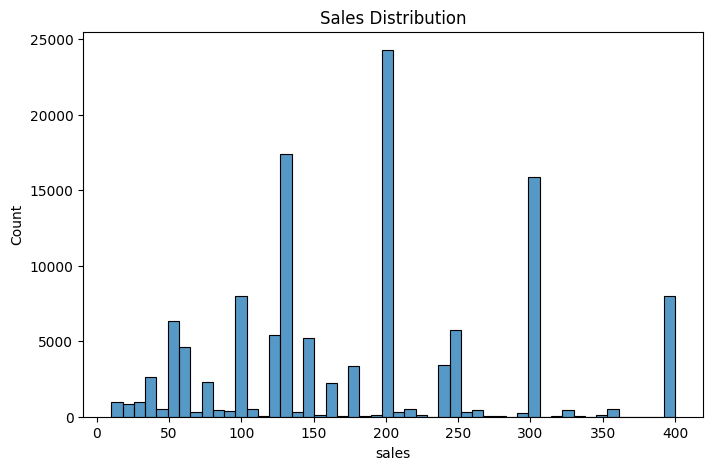

In [ ]:
# Sale Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['sales'], bins=50)
plt.title("Sales Distribution")
plt.show()

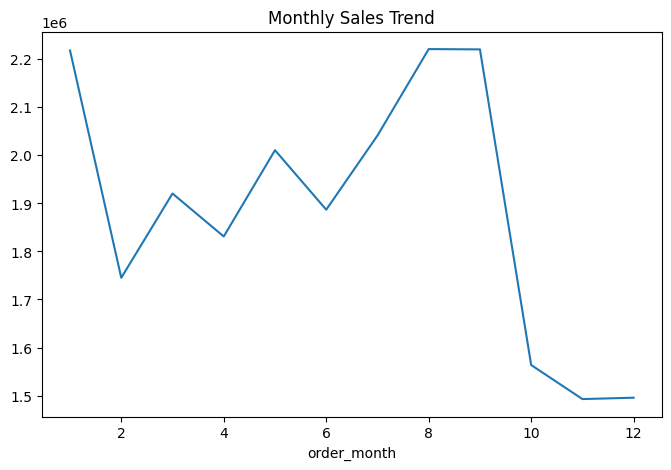

In [ ]:
# Monthly Sale Trends
monthly_sales = df.groupby('order_month')['sales'].sum()

monthly_sales.plot(kind='line', figsize=(8,5))
plt.title("Monthly Sales Trend")
plt.show()

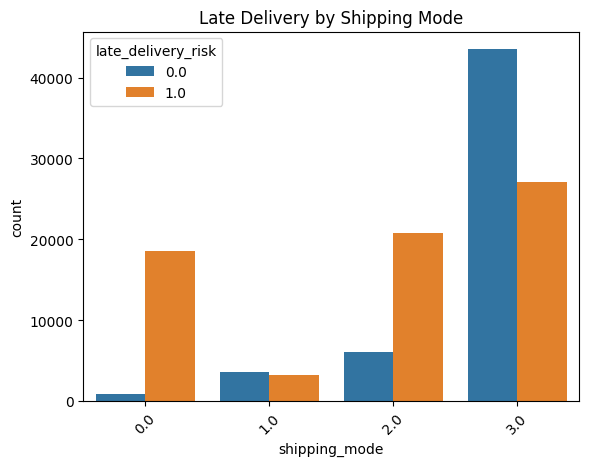

In [ ]:
# Late Deliver By Shipping Mode
sns.countplot(x='shipping_mode', hue='late_delivery_risk', data=df)
plt.xticks(rotation=45)
plt.title("Late Delivery by Shipping Mode")
plt.show()

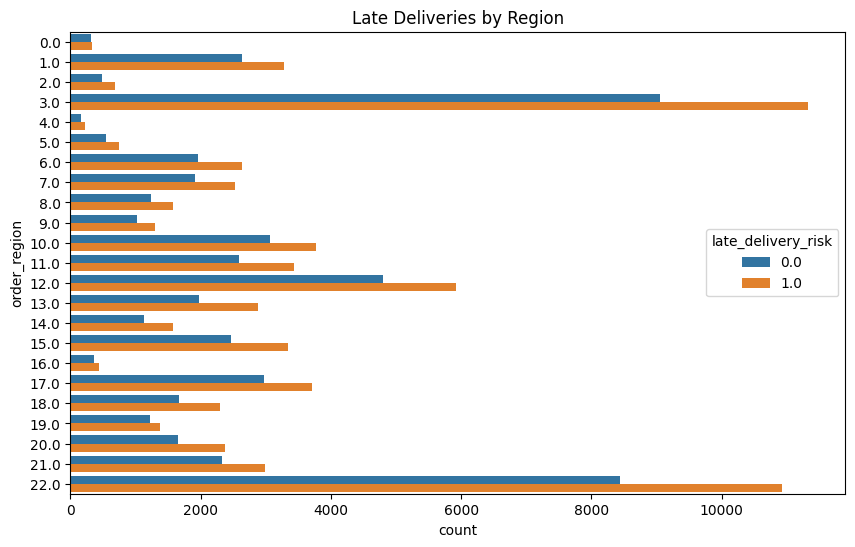

In [ ]:
# Late Delivr By Region
plt.figure(figsize=(10,6))

sns.countplot(
    y='order_region',
    hue='late_delivery_risk',
    data=df
)

plt.title("Late Deliveries by Region")
plt.show()

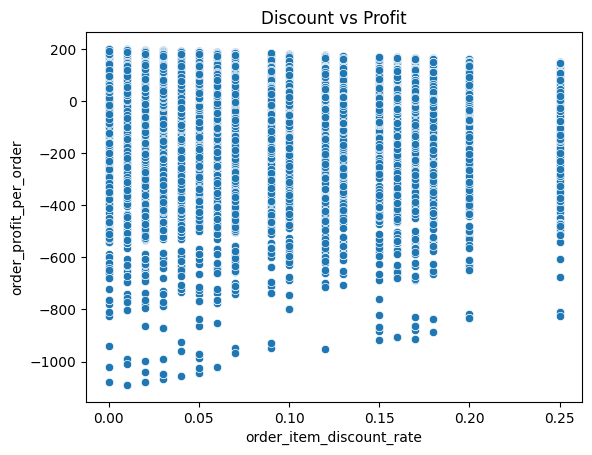

In [ ]:
# Profit Vs Discount
sns.scatterplot(
    x='order_item_discount_rate',
    y='order_profit_per_order',
    data=df
)

plt.title("Discount vs Profit")
plt.show()

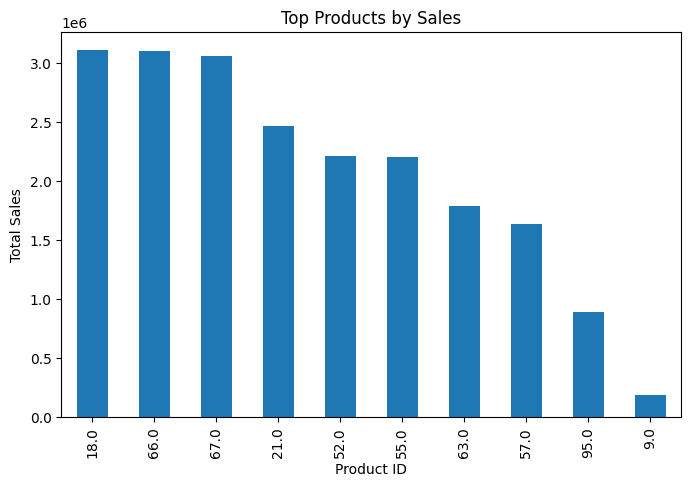

In [ ]:
# Top Products by Sales
top_products = df.groupby('product_name')['sales'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar', figsize=(8,5))

plt.title('Top Products by Sales')
plt.xlabel('Product ID')
plt.ylabel('Total Sales')
plt.show()

**Save Feature Engineered Dataset**

In [ ]:
df.to_csv("DataCo_feature_engineered.csv", index=False)